<a href="https://colab.research.google.com/github/Rasya-ai-web/Machine-Learning-Lab/blob/main/ML_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Building a Feedforward Neural Network Using TensorFlow / Keras


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [2]:

df = pd.read_csv("/content/iris_300.csv")

print("Dataset loaded successfully!")

print("\nFirst 10 rows:")
print(df.head(10))

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

Dataset loaded successfully!

First 10 rows:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm Species
0            5.1           3.5            1.4           0.2  setosa
1            4.9           3.0            1.4           0.2  setosa
2            4.7           3.2            1.3           0.2  setosa
3            4.6           3.1            1.5           0.2  setosa
4            5.0           3.6            1.4           0.2  setosa
5            5.4           3.9            1.7           0.4  setosa
6            4.6           3.4            1.4           0.3  setosa
7            5.0           3.4            1.5           0.2  setosa
8            4.4           2.9            1.4           0.2  setosa
9            4.9           3.1            1.5           0.1  setosa

Dataset Shape:
(300, 5)

Column Names:
Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [3]:
print("\nDataset Information:")
print(df.info())

print("\nClass Distribution:")
print(df.iloc[:, -1].value_counts())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  300 non-null    float64
 1   SepalWidthCm   300 non-null    float64
 2   PetalLengthCm  300 non-null    float64
 3   PetalWidthCm   300 non-null    float64
 4   Species        300 non-null    object 
dtypes: float64(4), object(1)
memory usage: 11.8+ KB
None

Class Distribution:
Species
setosa        100
versicolor    100
virginica     100
Name: count, dtype: int64


In [5]:
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = df["Species"]

In [6]:

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Encoded Classes:")
print(label_encoder.classes_)

Encoded Classes:
['setosa' 'versicolor' 'virginica']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (240, 4)
Testing data : (60, 4)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [9]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(16, activation="relu"),
    Dense(8, activation="relu"),

    Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2396 - loss: 1.1689 - val_accuracy: 0.2292 - val_loss: 1.1380
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2552 - loss: 1.1176 - val_accuracy: 0.2500 - val_loss: 1.0952
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2865 - loss: 1.0808 - val_accuracy: 0.2917 - val_loss: 1.0585
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3438 - loss: 1.0463 - val_accuracy: 0.3333 - val_loss: 1.0221
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3906 - loss: 1.0103 - val_accuracy: 0.4375 - val_loss: 0.9813
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5833 - loss: 0.9610 - val_accuracy: 0.6875 - val_loss: 0.9235
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7760 - loss: 0.8975 - val_accuracy: 0.8125 - val_loss: 0.8506
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7865 - loss: 0.8279 - val_accuracy: 0.8333 - val_

In [12]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test Accuracy Percentage:", accuracy * 100, "%")


Test Loss: 0.17624153196811676
Test Accuracy: 0.949999988079071
Test Accuracy Percentage: 94.9999988079071 %


In [13]:

y_probability = model.predict(X_test)


y_pred = y_probability.argmax(axis=1)

print("Prediction completed!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Prediction completed!


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("\nFeedforward Neural Network Results")
print("-----------------------------------")
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


Feedforward Neural Network Results
-----------------------------------
Accuracy: 0.95
Accuracy Percentage: 95.0 %


In [15]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[20  0  0]
 [ 0 18  2]
 [ 0  1 19]]


In [16]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.95      0.90      0.92        20
   virginica       0.90      0.95      0.93        20

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



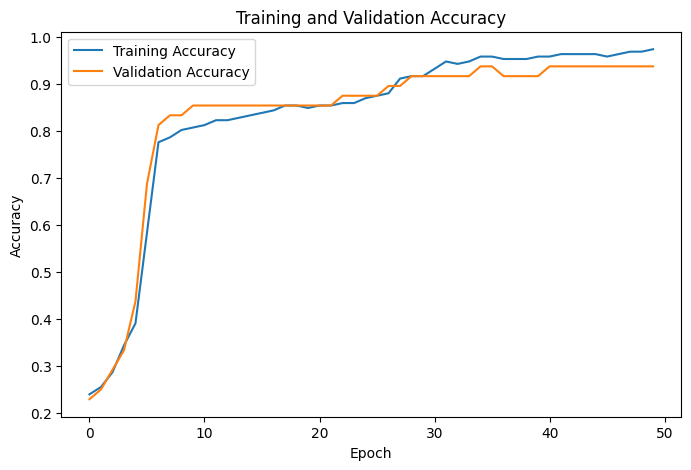

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

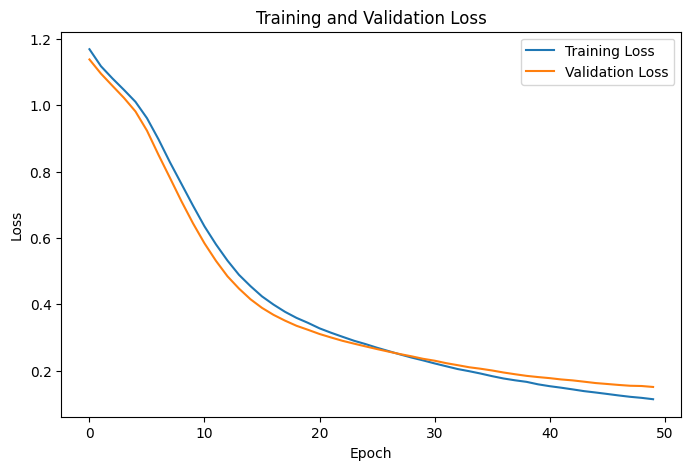

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

In [21]:
# ============================================================
# SAMPLE PREDICTION - FIXED
# ============================================================

sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
)

# Scale sample
sample_scaled = scaler.transform(sample)

# Predict
sample_probability = model.predict(sample_scaled, verbose=0)

# Get predicted class number
sample_prediction = sample_probability.argmax(axis=1)[0]

# Convert number back to class name
predicted_class = label_encoder.inverse_transform(
    [sample_prediction]
)[0]

print("\nSample Prediction")
print("------------------")
print("Input:", sample.iloc[0].tolist())
print("Predicted Class:", predicted_class)


Sample Prediction
------------------
Input: [5.1, 3.5, 1.4, 0.2]
Predicted Class: setosa
